In [3]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy


sys.path.append('..')
import plot_settings
plot_settings.apply()
colors = plot_settings.colors()

# Importing data

In [4]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [ ]:

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        delim_whitespace=True, comment="%", header=None)

    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)']
    return df


path = f'1_run'
data = read_data(path)
#rename columns
data.columns = ['u_par','C','t','V','I','F','u','U_eq']

# Normalize 
data['u'] = data['u'] * 1e5                 # 10 um = 1/100 mm
data['F'] = data['F'] * 1e-9                # GN
data['I'] = data['I'] * 1                   # A
data['eta'] = data['V'] - data['U_eq']    # V

/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_5935/4072924656.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [78]:
# Add numeric trajectory id for each unique (C, u_par) pair
data['trajectory'] = data.groupby(['C', 'u_par'], sort=False).ngroup()

# Optional lookup table (one row per trajectory)
trajectory_lookup = (
    data[['C', 'u_par', 'trajectory']]
    .drop_duplicates().sort_values('trajectory').reset_index(drop=True))

# print(trajectory_lookup)
# print(f"Number of trajectories: {trajectory_lookup['trajectory'].nunique()}")

# display(data)

In [33]:
# Batch data
feature_cols = ['I', 'u', 'U_eq']
target_cols  = ['V', 'F']

# Trajectories have unequal length — pad to longest and store a mask
traj_lengths = data.groupby('trajectory').size()
B     = len(traj_lengths)
T_max = traj_lengths.max()
Cx    = len(feature_cols)
Cy    = len(target_cols)

X_batched = torch.zeros(B, T_max, Cx)
Y_batched = torch.zeros(B, T_max, Cy)
mask      = torch.zeros(B, T_max, dtype=torch.bool)   # True where data exists

# Group by trajectory and fill the batches (rest = 0 (padding), mask = False)
for traj_id, grp in data.sort_values(['trajectory','t']).groupby('trajectory'):
    t_len = len(grp)
    X_batched[traj_id, :t_len, ...] = torch.tensor(grp[feature_cols].values, dtype=torch.float32)
    Y_batched[traj_id, :t_len, ...] = torch.tensor(grp[target_cols].values, dtype=torch.float32)
    mask[traj_id,      :t_len] = True

print(f"X_batched : {X_batched.shape}  (padded, use mask for loss)")
print(f"mask      : {mask.shape}")

X_batched : torch.Size([50, 5847, 3])  (padded, use mask for loss)
mask      : torch.Size([50, 5847])


In [ ]:
# Split
split   = int(B * 0.8)
X_train = X_batched[:split]   # (B_train, T, Cx)
Y_train = Y_batched[:split]   # (B_train, T, Cy)
X_test  = X_batched[split:]   # (B_test,  T, Cx)
Y_test  = Y_batched[split:]   # (B_test,  T, Cy)
mask_train = mask[:split]
mask_test  = mask[split:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


# DataLoaders
dataset_train = TensorDataset(X_train, Y_train, mask_train)
dataset_test  = TensorDataset(X_test,  Y_test, mask_test)

loader_train  = DataLoader(dataset_train, shuffle=True) # One traj at a time in training ----
loader_test   = DataLoader(dataset_test, shuffle=False)

Train: torch.Size([40, 5847, 3])  |  Test: torch.Size([10, 5847, 3])


In [92]:
def ECM_box(R, I, U_eq):
    """ V_t = U_eq(SoC) - R_NN(SoC) * I """
    return U_eq - R * I

first_rx = data.groupby('u')['F'].first()
k = abs(first_rx / (data.groupby('u')['u'].first()))
print(k.values[0])

def Mech_box(Fs, u, k=k.values[0]):
    """ F = Fs_NN(SoC) - k * delta_u """
    return Fs - k * u

def step(Fs, dFs, dt):
    return Fs + dt * dFs

0.5316439399331521


In [93]:
import torch.nn.functional as TF

class NeuralODE(nn.Module):
    def __init__(self, input_size=5, hidden_size=128):
        super().__init__()
        self.fs_dot_net = nn.Sequential(     # input: [Fs_t, soc_t, ]
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)   # output: dFs/dt
        )
        self.r0_net = nn.Sequential(
            nn.Linear(3, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def r_forward(self, x_b):
        R0_raw = self.r0_net(x_b)
        R0 = TF.softplus(R0_raw).squeeze(-1)  # Ensure positivity and (B, T)
        return R0

    def f_forward(self, x_b, Fs0):
        '''
        x_b : (B, T, 3)  (I, u, U_eq)
        Fs0 : (B,)       initial swelling force for each trajectory
        '''
        Fs_preds = []
        T = len(x_b[1])

        # Rollout
        for t in range(T):
            ode_input = torch.cat([Fs0.unsqueeze(0), x_b[:, t, :]])  # (5,)
            dF = self.fs_dot_net(ode_input.unsqueeze(0)).squeeze()
            Fs1 = step(Fs0, dF, dt=DT)
            Fs0 = Fs1
            Fs_preds.append(Fs0)
        return torch.stack(Fs_preds, dim=1)
    
    def forward(self, x_b, F0, dt=2.0):
        I = x_b[:, :, 0]    # (B, T)
        U_eq = x_b[:, :, 2] # (B, T)

        R0 = self.r_forward(x_b)
        # Fs = self.f_forward(F0, x_b[0])

        V_pred = ECM_box(R0, I, U_eq)   # (B, T)
        # F_pred = Mech_box(Fs)

        return V_pred#, F_pred

    
model = NeuralODE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [94]:
def masked_mse(y_pred, y_target, mask):
    '''
    y_pred, y_true : (B, T_max)
    mask           : (B, T_max)      True where valid
    '''
    sq_err = (y_pred - y_target) ** 2
    return sq_err[mask].mean()   

def training(epochs=30):
    history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}

    model.train()
    for ep in range(epochs):
        start_t = time.perf_counter()    
        ep_loss = 0.0
        tot_time = 0.

        for x_b, y_b, mask_b in loader_train:   # Start: one trajectory (B=1, T, C) at a time

            Fs0 = torch.zeros(x_b.shape[0])     # (B,) initial swelling force

            # print(Fs0.unsqueeze(0).shape, x_b[:, 2, :].shape, y_b.shape)
            
            V = model(x_b, Fs0) # (B, T)

            loss_V = masked_mse(V, y_b[:,:,0], mask_b) 
            # loss_F = TF.mse_loss(F, y_b[:,:,1])
            loss = loss_V # + loss_F

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        ep_loss += loss.item()
        ep_loss /= len(loader_train)

        history["loss"].append(ep_loss)
        # history["V_loss"].append(loss_V.item() / len(loader_train))
        # history["F_loss"].append(loss_F.item() / len(loader_train))
        end_t = time.perf_counter()
        history["time per ep"].append(end_t - start_t)   
        
        tot_time += end_t - start_t
       
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > 2*60:
            print("Early stopping: Total training time exceeded 3 minutes.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.2e} | V_loss {loss_V.item():.2e} | time {end_t - start_t:.2f}s")

    return history   

In [95]:
history = training(epochs=50)

ETA: 0.06 min
Epoch 1 | loss 1.24e-02 | V_loss 4.97e-01 | time 0.07s
Epoch 2 | loss 7.65e-03 | V_loss 3.06e-01 | time 0.05s
Epoch 3 | loss 7.68e-04 | V_loss 3.07e-02 | time 0.04s
Epoch 4 | loss 2.36e-03 | V_loss 9.44e-02 | time 0.04s
Epoch 5 | loss 2.46e-03 | V_loss 9.85e-02 | time 0.04s
Epoch 6 | loss 1.39e-03 | V_loss 5.54e-02 | time 0.05s
Epoch 7 | loss 2.17e-04 | V_loss 8.68e-03 | time 0.11s
Epoch 8 | loss 2.93e-03 | V_loss 1.17e-01 | time 0.11s
Epoch 9 | loss 1.93e-04 | V_loss 7.74e-03 | time 0.09s
Epoch 10 | loss 9.28e-04 | V_loss 3.71e-02 | time 0.06s
Epoch 11 | loss 2.25e-04 | V_loss 9.01e-03 | time 0.05s
Epoch 12 | loss 1.60e-04 | V_loss 6.40e-03 | time 0.05s
Epoch 13 | loss 2.27e-04 | V_loss 9.09e-03 | time 0.06s
Epoch 14 | loss 6.41e-04 | V_loss 2.57e-02 | time 0.06s
Epoch 15 | loss 2.63e-04 | V_loss 1.05e-02 | time 0.06s
Epoch 16 | loss 2.52e-03 | V_loss 1.01e-01 | time 0.06s
Epoch 17 | loss 2.12e-04 | V_loss 8.46e-03 | time 0.06s
Epoch 18 | loss 3.60e-04 | V_loss 1.44e-02 

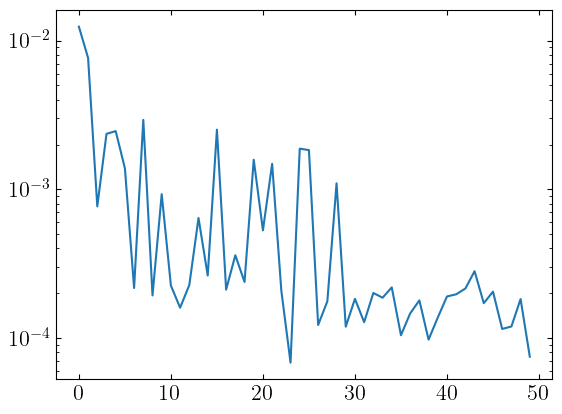

In [119]:
plt.semilogy(history["loss"], label="Total Loss")

torch.Size([10, 5847, 1]) torch.Size([10, 5847, 1]) torch.Size([10, 5847, 1])


Text(0.5, 0, 'Time step')

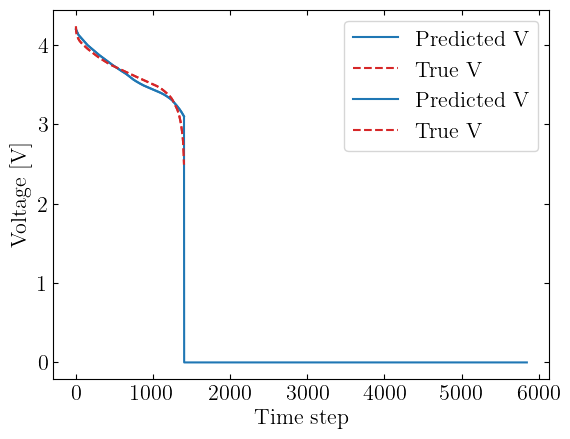

In [118]:
def evaluate(model, x_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:, :, 0].unsqueeze(-1)  # (B, T, 1)
        u = x_test[:, :, 1].unsqueeze(-1)  # (B, T, 1)
        U_eq = x_test[:, :, 2].unsqueeze(-1)  # (B, T, 1)

        print(I.shape, u.shape, U_eq.shape)

        # R0 = model.r_forward(x_test)
        # V_pred = ECM_box(R0, I, U_eq)

        V_pred = model(x_test, torch.zeros(1))  # (B, T)  # Using forward for V_pred directly
    
    return V_pred.detach().numpy()

V_pred = evaluate(model, X_test)

idx = 6

t_max = mask_test[idx].sum()
t_len = np.linspace(0, t_max-1, t_max)
plt.plot(t_len, V_pred[idx, :t_max], color=colors[0], label="Predicted V")
plt.plot(t_len, Y_test[idx, :t_max, 0], linestyle='--', color=colors[1], label="True V")
plt.legend()
plt.ylabel("Voltage [V]")
plt.xlabel("Time step")


plt.plot(V_pred[idx, :], color=colors[0], label="Predicted V")
plt.plot(t_len, Y_test[idx, :t_max, 0], linestyle='--', color=colors[1], label="True V")
plt.legend()
plt.ylabel("Voltage [V]")
plt.xlabel("Time step")